In [ ]:
!pip install matplotlib
!pip install tqdm
!pip install scikit-learn
!pip install datasets
!pip install transformers

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

from ap_ood import APOOD
from ap_ood.utils.plot_util import plot_histograms

/system/apps/userenv/hofmann/ap-ood/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# AP-OOD Natural Language Example

This example demonstrates the OOD detection capabilities of our method on [Pegasus](https://huggingface.co/google/pegasus-xsum) trained on the [xsum](https://huggingface.co/datasets/EdinburghNLP/xsum) data set:

We will perform OOD detection by training only the ID data set (XSUM containing news articles from BBC), and we want to be able to detect news articles from CNN as OOD.

## Loading and Pre-Processing

In [ ]:
transformer = AutoModel.from_pretrained('google/pegasus-xsum').to('cuda').eval()
tokenizer = AutoTokenizer.from_pretrained('google/pegasus-xsum')

id_train = load_dataset('EdinburghNLP/xsum', split='train')
id_test = load_dataset('EdinburghNLP/xsum', split='test')

ood_test = load_dataset('abisee/cnn_dailymail', '1.0.0', split='test')

## Training

In [ ]:
model = APOOD(
    feature_dim=1024,
    n_heads=512,
    n_queries=2,
    beta=0.25,
    similarity='dot',
).to('cuda')

In [ ]:
n_steps = 250  # here we only use 250 steps to save time

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.)  # weight_decay=0. keeps the parameters from converging to the trivial minimum at 0.

loader = torch.utils.data.DataLoader(id_train, shuffle=True, batch_size=512)

pbar = tqdm(total=n_steps)

def get_scores(documents, transformer, model):
    tokens = tokenizer(documents, padding="max_length", max_length=512, truncation=True, return_tensors="pt").to('cuda')

    with torch.no_grad():
        token_embeddings = transformer.encoder(**tokens)

    return model(token_embeddings.last_hidden_state, tokens['attention_mask'].bool())  # supply embeddings and masks to the model

for i, batch in enumerate(loader):

    scores = get_scores(batch['document'], transformer, model)
    loss = torch.mean(scores)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.update()
    if i == n_steps - 1:
        break

pbar.close()


100%|██████████| 250/250 [1:03:50<00:00, 15.32s/it]


In [ ]:
def partial_fit_mean(documents, transformer, model):
    tokens = tokenizer(documents, padding="max_length", max_length=512, truncation=True, return_tensors="pt").to('cuda')

    with torch.no_grad():
        token_embeddings = transformer.encoder(**tokens)

    model.partial_fit_mean(token_embeddings.last_hidden_state, tokens['attention_mask'].bool())  # supply embeddings and masks to the model

pbar = tqdm(total=n_steps)

for i, batch in enumerate(loader):
    partial_fit_mean(batch['document'], transformer, model)
    pbar.update()
    if i == n_steps - 1:
        break

pbar.close()


 90%|█████████ | 225/250 [56:30<06:28, 15.55s/it] 

## Evaluation
### Visualize OOD Scores for XSUM (Test) and CNN/DailyMail

Now that the model is trained, let's look at the scores it assigns to the test data.

Since the model only saw XSUM sequences during training, it should recognize them as normal and give them high scores (=low distances). Conversely, the CNN/DailyMail sequences should look unfamiliar to the model, resulting in much lower scores (=higher distances).

Ideally, we want to see a clear separation between the Positive (blue) and Negative (orange) distributions.

 83%|████████▎ | 19/23 [02:53<00:36,  9.14s/it]


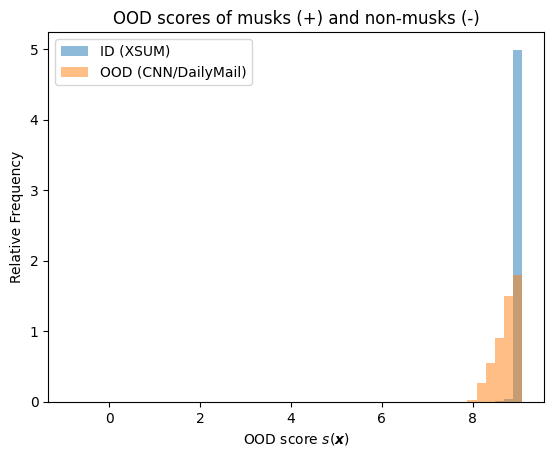

In [ ]:
model.eval()  # model.eval() will make the model use the mean fitted by calling partial_fit_mean

sns.set_theme(style="whitegrid")

def get_scores_dataset(dataset, transformer, model, n_samples=10_000, document_key='document'):
    loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

    scores = []
    with torch.no_grad():
        for batch in tqdm(loader):
            scores.append(get_scores(batch[document_key], transformer, model))
            if sum(len(s) for s in scores) >= n_samples:
                return torch.cat(scores, dim=0)


id_scores = -get_scores_dataset(id_test, transformer, model).cpu()
ood_scores = -get_scores_dataset(ood_test, transformer, model, document_key='article').cpu()
plot_histograms([id_scores.detach(), ood_scores.detach()], ['ID (XSUM)', 'OOD (CNN/DailyMail)'], bins=50, density=True)
plt.legend()
plt.xlabel('OOD score $s(\\boldsymbol{x})$')
plt.title('OOD scores of XSUM sequences (+) and CNN/DailyMail sequences (-)')
plt.show()

### ROC curve

We use the Area Under the Receiver Operating Characteristic (AUROC) to quantify how well our model distinguishes between Musks and Non-Musks.

Since we obtained an AUROC of 0.98, this indicates the model is highly effective.

We also plot the ROC curve below to visualize the trade-off for detecting OOD examples at different thresholds for the true positive rate.

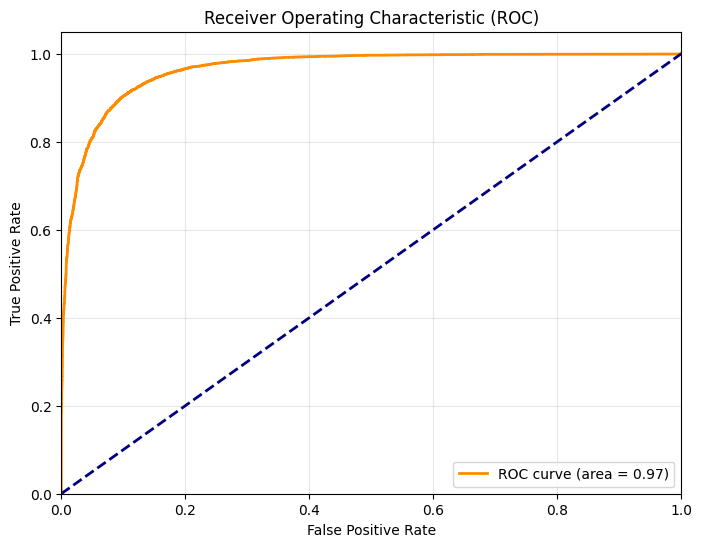

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

# Prepare labels and scores (as you did in cell 13)
labels = np.concatenate([np.zeros_like(ood_scores), np.ones_like(id_scores)])
scores = np.concatenate([ood_scores, id_scores]) # Negate because lower score = ID (usually)

# Calculate curve
fpr, tpr, _ = roc_curve(labels, scores)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(labels, scores):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()